In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Q3 a

In [2]:
# Time settings
t0 = 0
tf = 10
t_eval = np.linspace(t0, tf, 1000)

# ode1 ODE
def ode1(t, y, u):
    x = y[0]
    xdot = y[1]

    dxdt = xdot
    dxdotdt = -5*xdot - 6*x + u(t)

    return [dxdt, dxdotdt]

# Step input
def step_input(t):
    return 1

# Zero input
def zero_input(t):
    return 0

# Impulse approximation
epsilon = 0.01
def impulse_input(t):
    return 1/epsilon if 0 <= t <= epsilon else 0


In [3]:
#Numerical solutions
# Step
sol_step = solve_ivp(lambda t,y: ode1(t,y,step_input),
                     [t0,tf],[0,0],t_eval=t_eval)

# Impulse
sol_imp = solve_ivp(lambda t,y: ode1(t,y,impulse_input),
                    [t0,tf],[0,0],t_eval=t_eval)

# IC case 1
sol_ic1 = solve_ivp(lambda t,y: ode1(t,y,zero_input),
                    [t0,tf],[1,0],t_eval=t_eval)

# IC case 2
sol_ic2 = solve_ivp(lambda t,y: ode1(t,y,zero_input),
                    [t0,tf],[0,1],t_eval=t_eval)


# Analytical solutions
t = t_eval

x_step = 1/6 - np.exp(-2*t)/2 + np.exp(-3*t)/3
x_imp = np.exp(-2*t) - np.exp(-3*t)
x_ic1 = 3*np.exp(-2*t) - 2*np.exp(-3*t)
x_ic2 = np.exp(-2*t) - np.exp(-3*t)


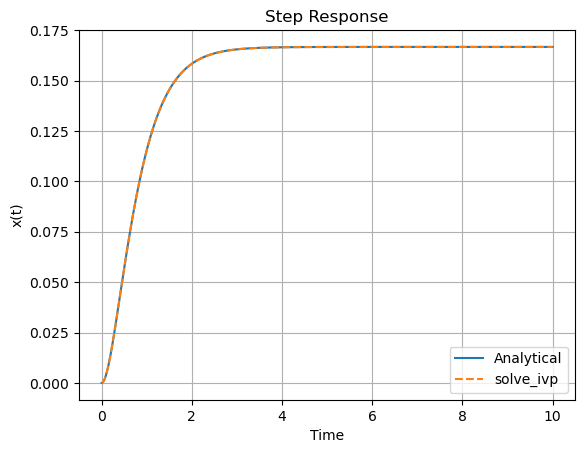

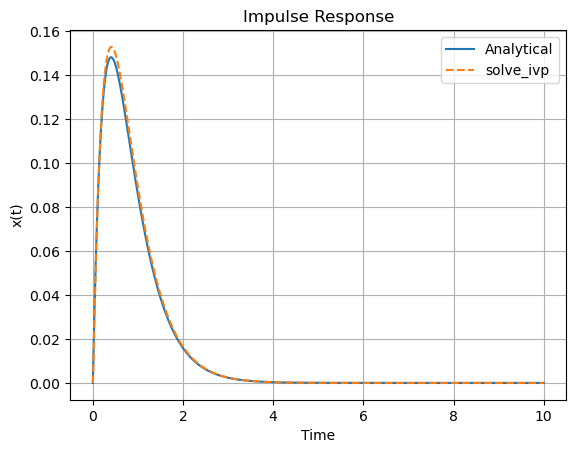

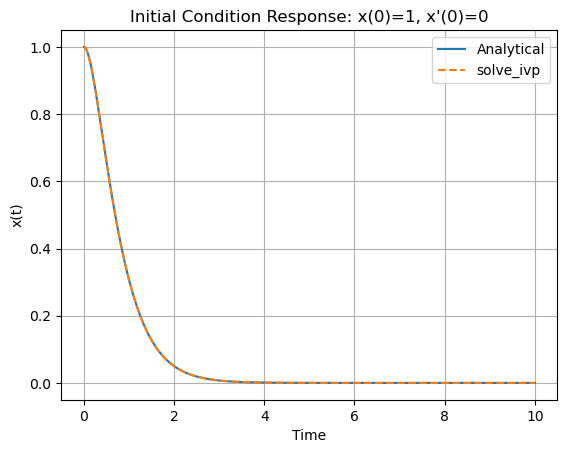

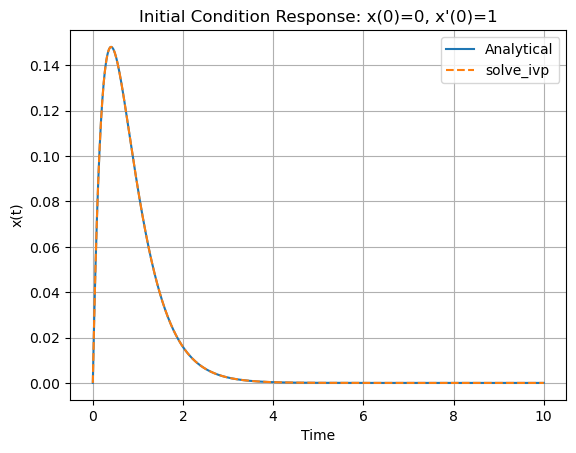

In [4]:
# Plot 1: Step Response
plt.figure()
plt.plot(t, x_step, label="Analytical")
plt.plot(sol_step.t, sol_step.y[0],'--', label="solve_ivp")
plt.title("Step Response")
plt.xlabel("Time")
plt.ylabel("x(t)")
plt.legend()
plt.grid()


# Plot 2: Impulse Response
plt.figure()
plt.plot(t, x_imp, label="Analytical")
plt.plot(sol_imp.t, sol_imp.y[0],'--', label="solve_ivp")
plt.title("Impulse Response")
plt.xlabel("Time")
plt.ylabel("x(t)")
plt.legend()
plt.grid()


# Plot 3: IC (1,0)
plt.figure()
plt.plot(t, x_ic1, label="Analytical")
plt.plot(sol_ic1.t, sol_ic1.y[0],'--', label="solve_ivp")
plt.title("Initial Condition Response: x(0)=1, x'(0)=0")
plt.xlabel("Time")
plt.ylabel("x(t)")
plt.legend()
plt.grid()


# Plot 4: IC (0,1)
plt.figure()
plt.plot(t, x_ic2, label="Analytical")
plt.plot(sol_ic2.t, sol_ic2.y[0],'--', label="solve_ivp")
plt.title("Initial Condition Response: x(0)=0, x'(0)=1")
plt.xlabel("Time")
plt.ylabel("x(t)")
plt.legend()
plt.grid()

plt.show()

Q3 b

In [5]:
# System dynamics
def ode2(t, y, u):
    x, xdot = y
    dxdt = xdot
    dxdotdt = 2*xdot - 2*x + u(t)
    return [dxdt, dxdotdt]

In [6]:
# Numerical Solutions
sol_step = solve_ivp(lambda t,y: ode2(t,y,step_input),
                     [t0,tf],[0,0],t_eval=t_eval)

sol_imp = solve_ivp(lambda t,y: ode2(t,y,impulse_input),
                    [t0,tf],[0,0],t_eval=t_eval)

sol_ic1 = solve_ivp(lambda t,y: ode2(t,y,zero_input),
                    [t0,tf],[1,0],t_eval=t_eval)

sol_ic2 = solve_ivp(lambda t,y: ode2(t,y,zero_input),
                    [t0,tf],[0,1],t_eval=t_eval)


# Analytical solutions
t = t_eval

x_step = 0.5 - 0.5*np.exp(t)*np.cos(t) + 0.5*np.exp(t)*np.sin(t)
x_imp = np.exp(t)*np.sin(t)
x_ic1 = np.exp(t)*(np.cos(t) - np.sin(t))
x_ic2 = np.exp(t)*np.sin(t)

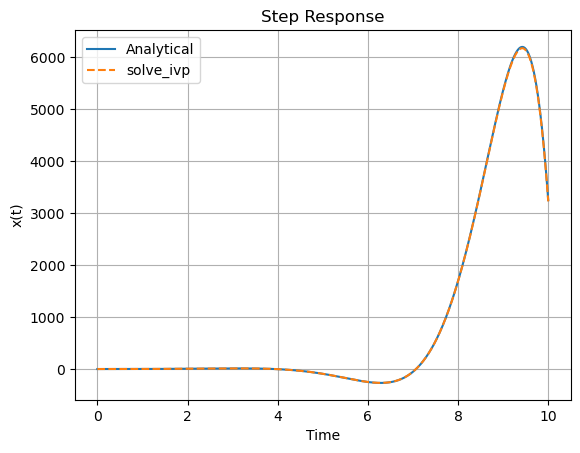

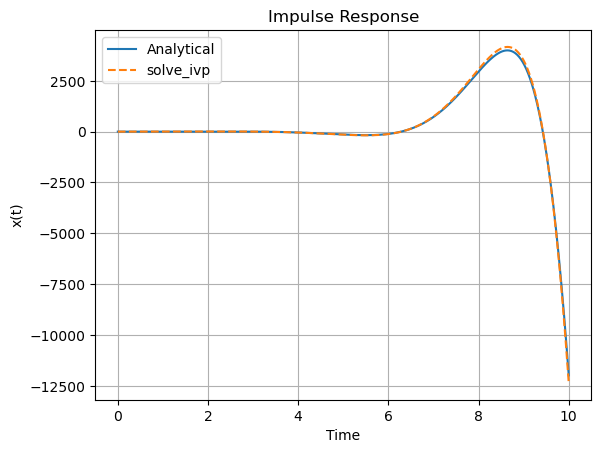

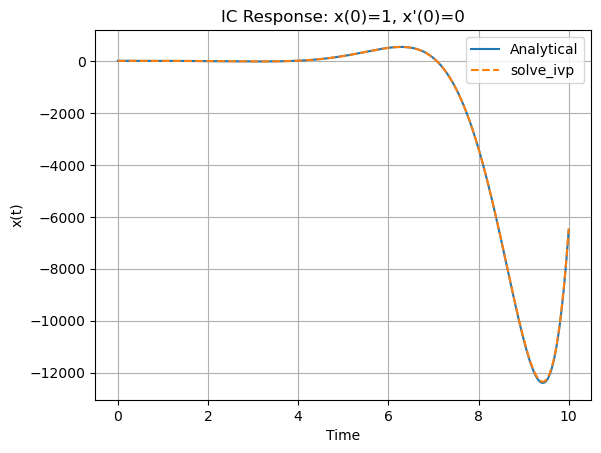

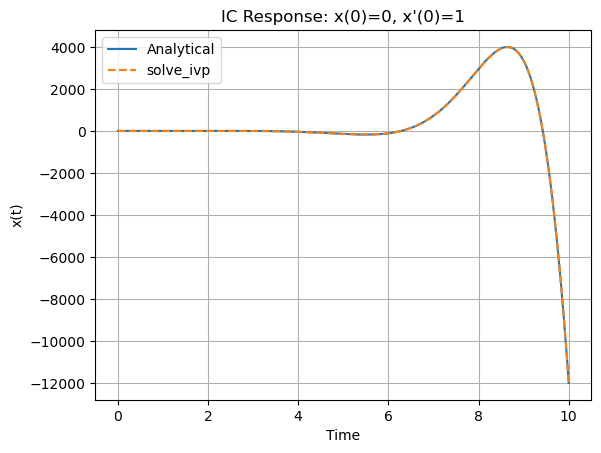

In [7]:
# Plot 1: Step
plt.figure()
plt.plot(t, x_step, label="Analytical")
plt.plot(sol_step.t, sol_step.y[0],'--', label="solve_ivp")
plt.title("Step Response")
plt.xlabel("Time")
plt.ylabel("x(t)")
plt.legend()
plt.grid()


# Plot 2: Impulse
plt.figure()
plt.plot(t, x_imp, label="Analytical")
plt.plot(sol_imp.t, sol_imp.y[0],'--', label="solve_ivp")
plt.title("Impulse Response")
plt.xlabel("Time")
plt.ylabel("x(t)")
plt.legend()
plt.grid()


# Plot 3: IC (1,0)
plt.figure()
plt.plot(t, x_ic1, label="Analytical")
plt.plot(sol_ic1.t, sol_ic1.y[0],'--', label="solve_ivp")
plt.title("IC Response: x(0)=1, x'(0)=0")
plt.xlabel("Time")
plt.ylabel("x(t)")
plt.legend()
plt.grid()


# Plot 4: IC (0,1)
plt.figure()
plt.plot(t, x_ic2, label="Analytical")
plt.plot(sol_ic2.t, sol_ic2.y[0],'--', label="solve_ivp")
plt.title("IC Response: x(0)=0, x'(0)=1")
plt.xlabel("Time")
plt.ylabel("x(t)")
plt.legend()
plt.grid()

plt.show()